# Retained states and every PCAT proposal

This notebook runs a seeded simulated two-line Voigt spectrum. The first animation contains retained chain-state frames at the configured plotting cadence. The second contains every proposed candidate before the Metropolis-Hastings decision, including candidates that are rejected. This short run demonstrates output semantics rather than posterior convergence.

In [1]:
from IPython.display import Image, display
import numpy as np

from pcat.main import readfile
from proposal_state_animation import EXAMPLE_PATH, RUN_NAME, run_example

products = run_example(number_sweeps=120)
worker = readfile(str(EXAMPLE_PATH / "data" / "outp" / RUN_NAME / "gdatmodi0000post"))
accepted = np.asarray(worker.listpostboolpropaccp).reshape(-1).astype(bool)
proposal_types = np.asarray(worker.listpostindxproptype).reshape(-1).astype(int)
jacobian = np.asarray(worker.listpostljcb).reshape(-1)
{
    "sweeps": accepted.size,
    "accepted": int(accepted.sum()),
    "rejected": int((~accepted).sum()),
    "proposal_counts": {int(kind): int(np.sum(proposal_types == kind)) for kind in np.unique(proposal_types)},
    "nonzero_jacobians": int(np.count_nonzero(jacobian)),
    "jacobian_acceptance_summary": products["jacobian_summary"],
}

{'sweeps': 120,
 'accepted': 19,
 'rejected': 101,
 'proposal_counts': {0: 26, 1: 17, 2: 25, 3: 29, 4: 23},
 'nonzero_jacobians': 45,
 'jacobian_acceptance_summary': {'split': {'count': 20,
   'mean_actual_probability': 0.013848189426685364,
   'mean_without_jacobian': 0.03902198982688594,
   'observed_acceptance_fraction': 0.0,
   'median_log_jacobian': -1.0359708321730061},
  'merge': {'count': 23,
   'mean_actual_probability': 0.0,
   'mean_without_jacobian': 0.0,
   'observed_acceptance_fraction': 0.0,
   'median_log_jacobian': -1.859186383870596}}}

## Retained chain states

These frames show the state retained by the Markov chain at the sparse plotting cadence. A rejected proposal therefore leaves the displayed chain state unchanged.

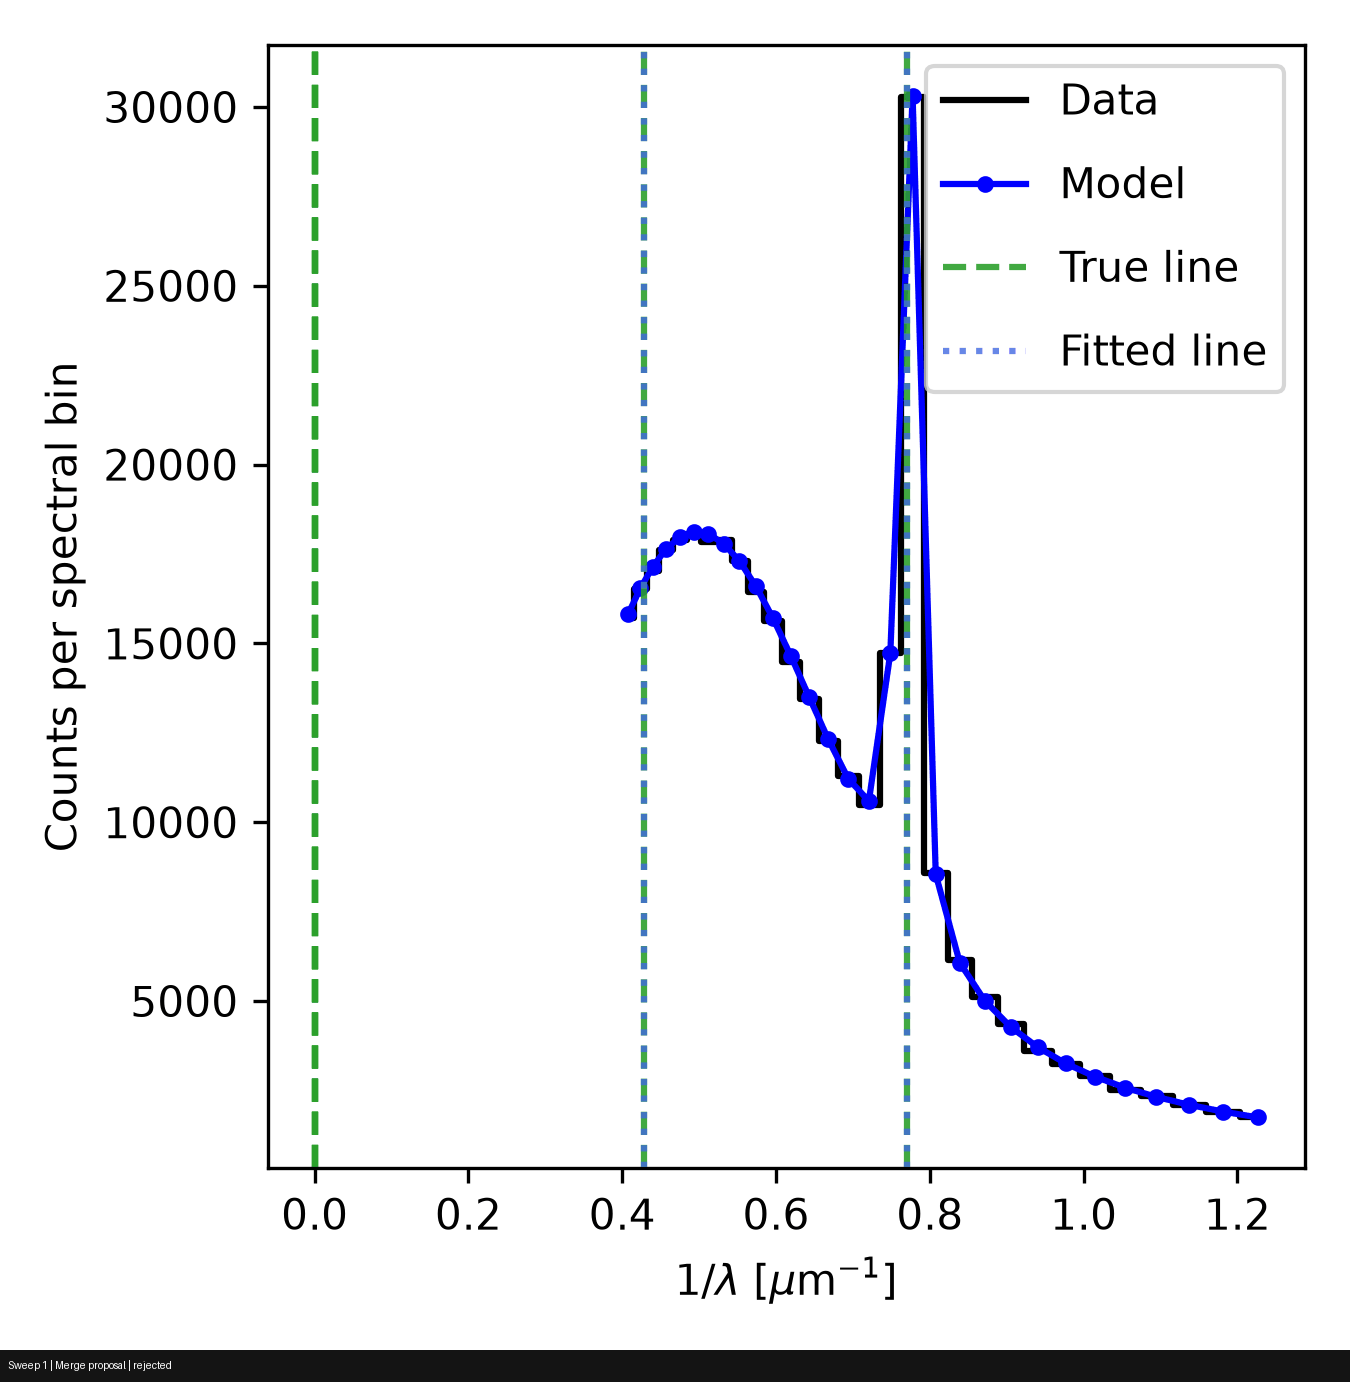

In [2]:
display(Image(filename=str(products["posterior_animation"])))

## Split/merge Jacobian

For a parent amplitude $F$ split into $rF$ and $(1-r)F$, PCAT's transformation has $\log|J|=\log F$. The reverse merge contributes the negative term. The acceptance log ratio is $\log\alpha=\Delta\log\pi+\log(q_r/q_f)+\log|J|$, clipped at zero when converted to a probability. The figure compares each valid split/merge proposal with its counterfactual probability after omitting only $\log|J|$, then shows how the median observed Jacobian shifts the acceptance curve. Counterfactuals reuse the same proposed states and are not a second sampled chain.

## Every proposed candidate

Set `boolmakeanimprop=True` to write one frame per sweep. Each frame compares the current and candidate predictions and unit-prior coordinates, then reports the move type, prior-support result, acceptance probability, accept/reject result, log posterior change, proposal-density ratio, and Jacobian.

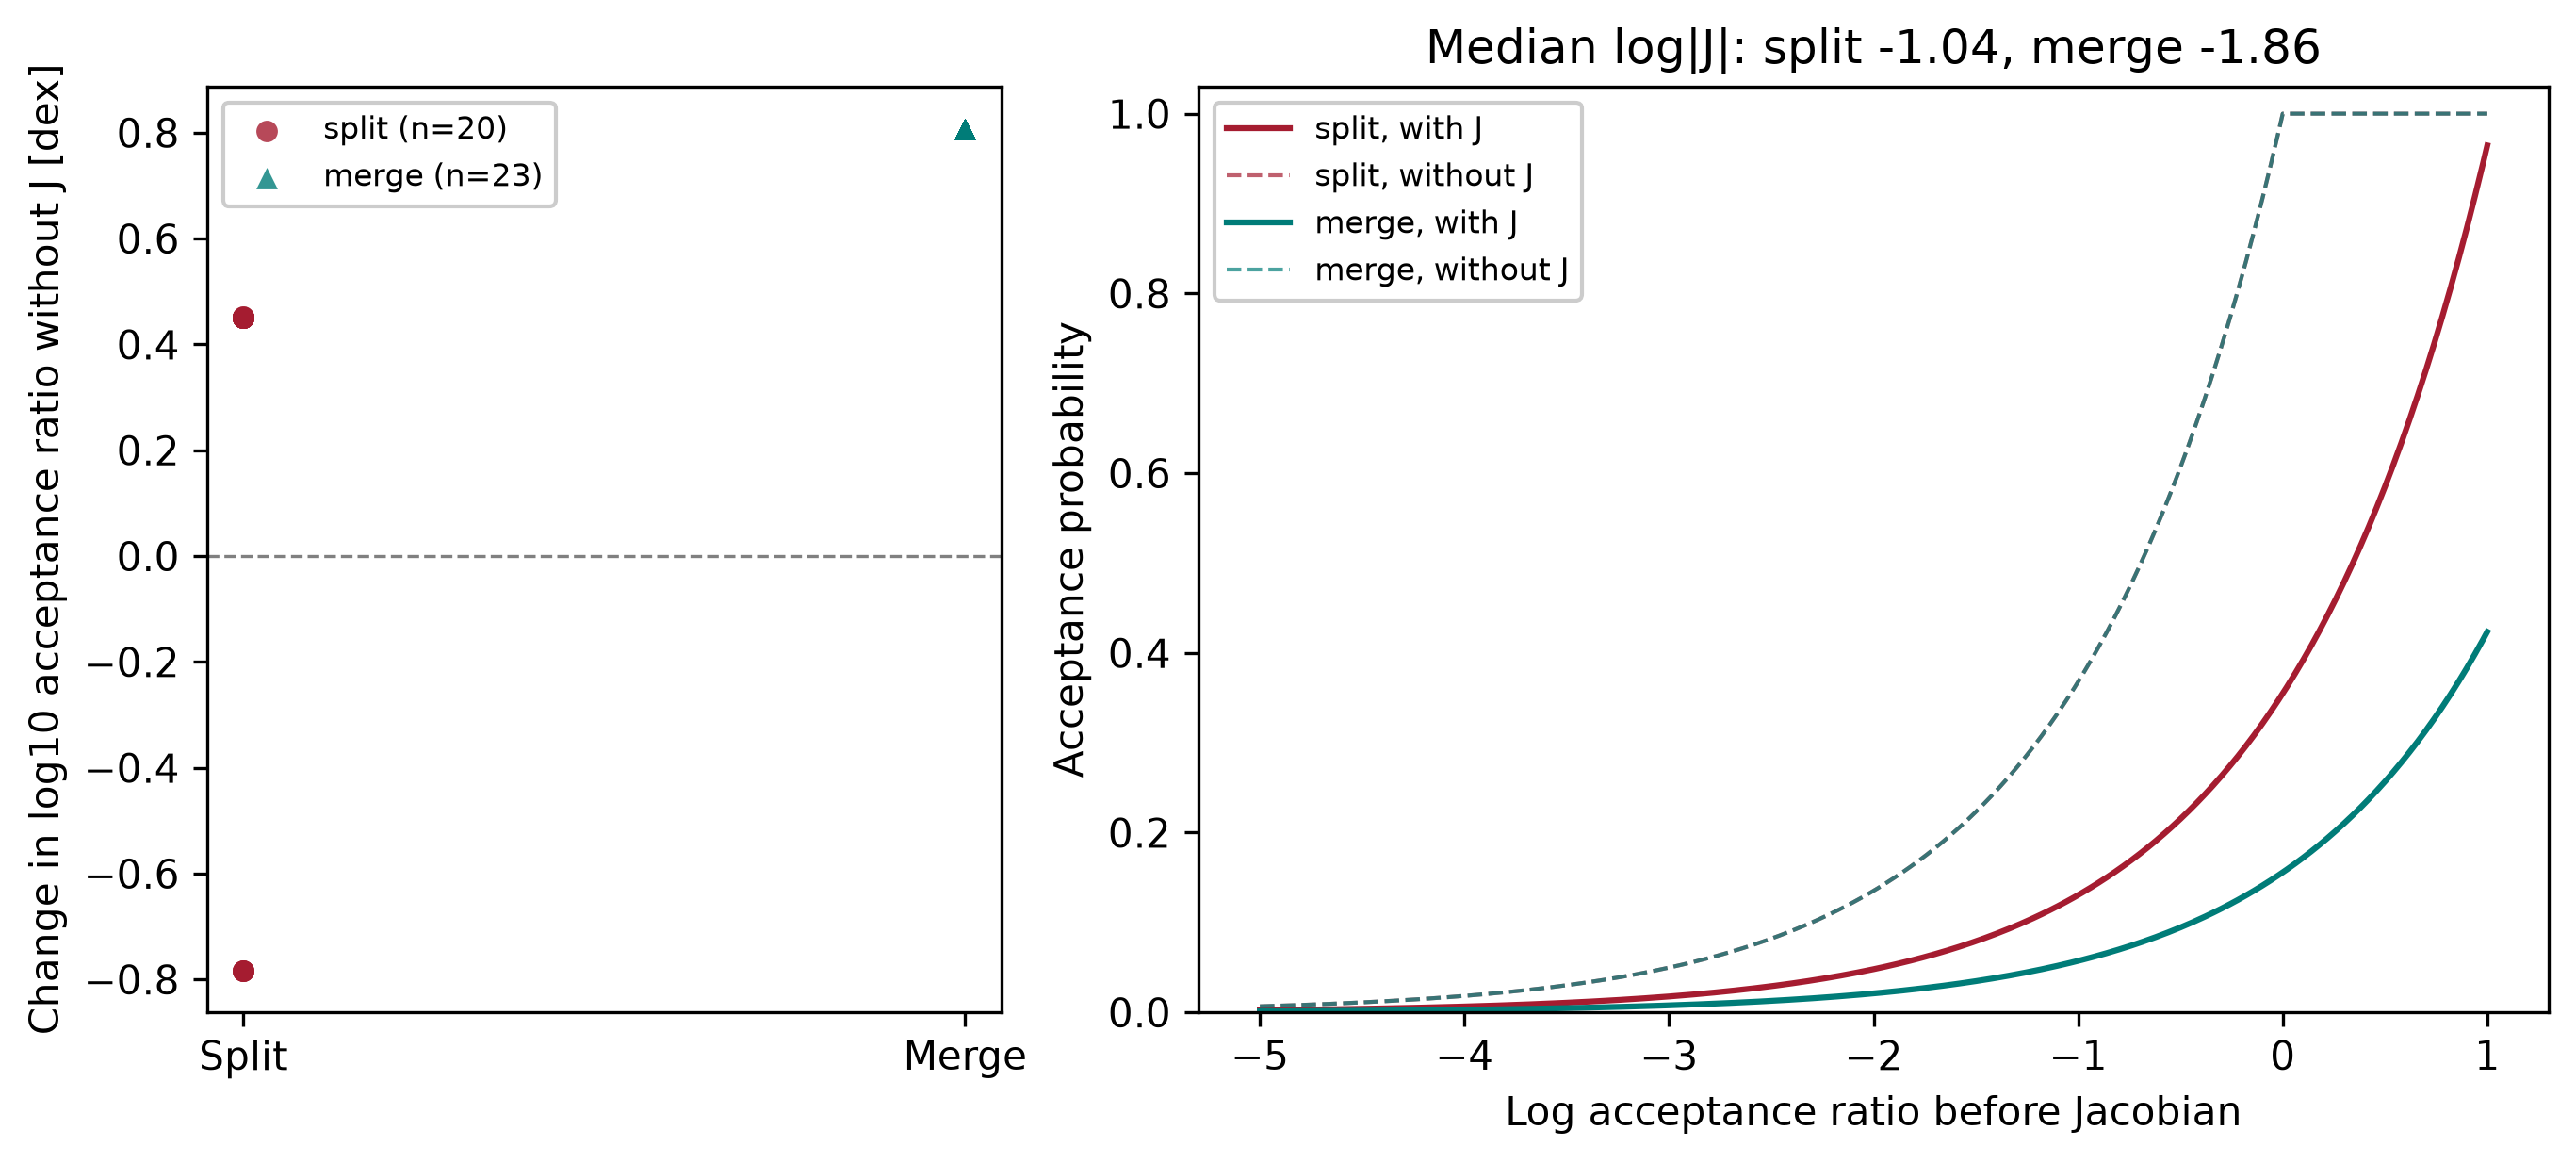

{'split': {'count': 20, 'mean_actual_probability': 0.013848189426685364, 'mean_without_jacobian': 0.03902198982688594, 'observed_acceptance_fraction': 0.0, 'median_log_jacobian': -1.0359708321730061}, 'merge': {'count': 23, 'mean_actual_probability': 0.0, 'mean_without_jacobian': 0.0, 'observed_acceptance_fraction': 0.0, 'median_log_jacobian': -1.859186383870596}}


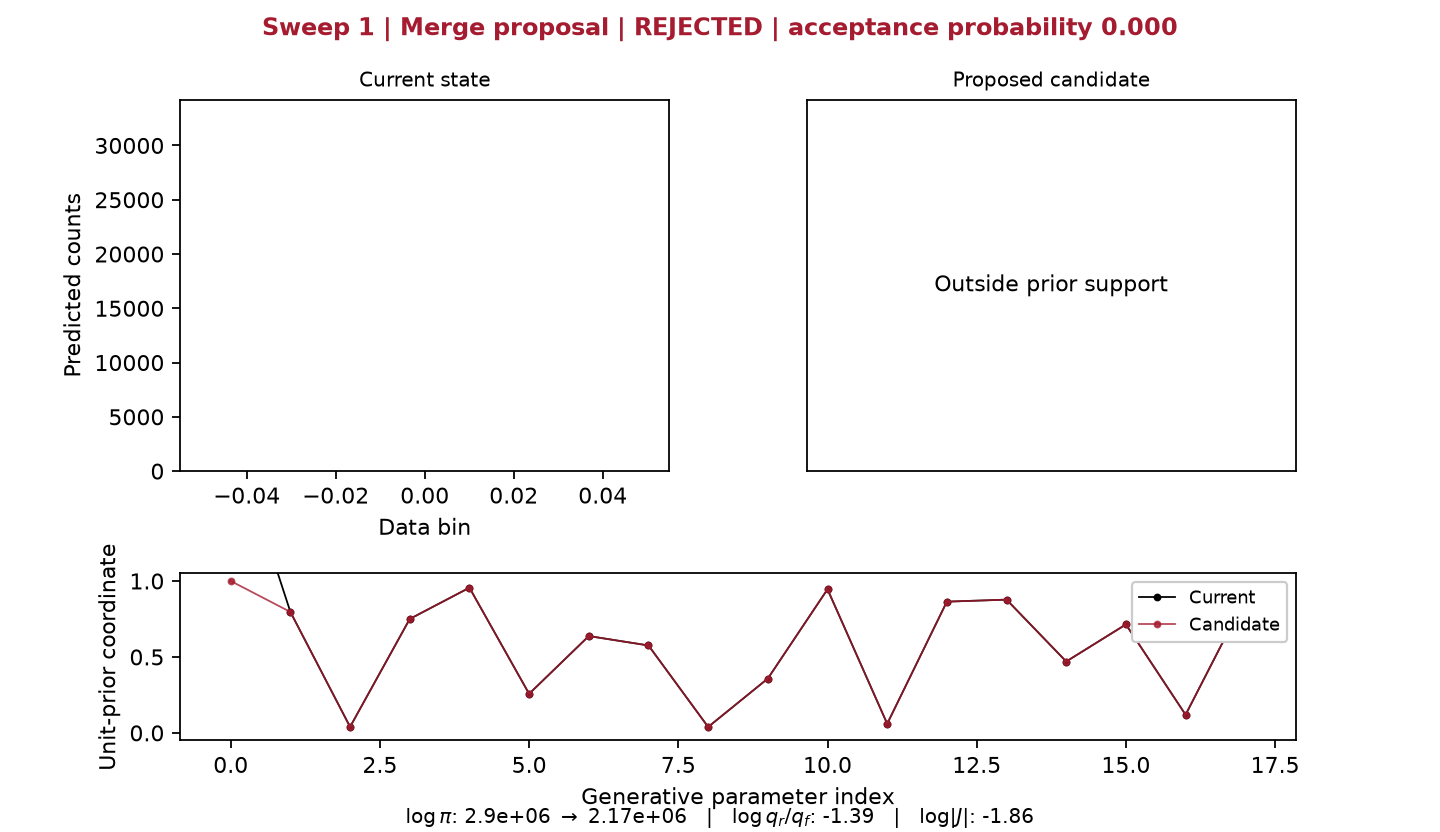

In [3]:
display(Image(filename=str(products["jacobian_figure"])))
print(products["jacobian_summary"])
display(Image(filename=str(products["proposal_animation"])))